# Dataset Description

### Goal Recap
The goal of this project is to perform a spatial analysis of restaurants in New York City using Yelp data. We aim to understand how geographic location, pricing, and user engagement (in the form of reviews and ratings) contribute to restaurant performance. By analyzing spatial clusters and associated metadata, we hope to uncover insights that can inform business strategy, location planning, and competitive positioning within NYC’s dense food service market.

### Factors (Features)
- **Latitude & Longitude:** Used for spatial clustering and location-based analysis.
- **Price Range:** Indicates affordability, categorized into `0-10`, `11-30`, `31-60`, and `60+`.
- **Review Count:** Proxy for popularity and customer engagement.
- **Rating:** Average customer satisfaction score on a scale of 1–5.
- **City, State, Postal Code:** Used for geographic filtering or potential merging with external data (e.g. census).

### Target (for analysis and modeling)
- **Clustering Target:** Identify groups of restaurants that exhibit similar spatial and performance characteristics.
- **Performance Indicators:** High rating combined with high review count, especially within certain price brackets or regions.

This dataset will serve as the foundation for clustering, visual exploration, and potentially predictive modeling of restaurant success in NYC.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/new-york-city-census-data/census_block_loc.csv
/kaggle/input/new-york-city-census-data/nyc_census_tracts.csv
/kaggle/input/nyc-restaurants/PyRestaurants_data.csv


# Census dataset

In [3]:
census = pd.read_csv("/kaggle/input/new-york-city-census-data/nyc_census_tracts.csv")
# Columns that will be used in our project
hot_columns = [
    'CensusTract', 'County', 'Borough', 'TotalPop', 'Men', 'Women',
    'Hispanic', 'White', 'Black', 'Native', 'Asian',
    'Citizen', 'Income','Transit', 'Walk', 
    'Drive', 'MeanCommute', 'Employed', 'Unemployment'
]

census_loc = pd.read_csv("/kaggle/input/new-york-city-census-data/census_block_loc.csv")
census = census[hot_columns]
census_loc = census_loc[census_loc["State"]=="NY"]

# Merging census tract location.
- We have the census data and the location (lat, long) in a different dataset
- Merge the two dataset to use and prepare the dataset for our project

In [4]:
census_loc = census_loc.copy()
census_loc["CensusTract"] = census_loc["BlockCode"] // 10000  # remove last 4 digits

# Group by CensusTract and take the average lat/lon
census_block = census_loc.groupby("CensusTract").agg({
    "Latitude": "mean",
    "Longitude": "mean"
}).reset_index()
census = census.merge(census_block, on="CensusTract", how="left")

## Now our census will also have longitude and latitude data

# NYC Restaurants 

In [5]:
restaurants = pd.read_csv("/kaggle/input/nyc-restaurants/PyRestaurants_data.csv")

# Renaming the dataset columns to human readable.
restaurants = restaurants.rename(columns={"id":"Restaurant ID", "name":"Restaurants", "phone":"Phone Number","location.address1":"Adress",
                                          "location.address2":"Address Two","location.city":"City","location.state":"State","location.country":"Country","location.state":"State",
                                           "price":"Price","rating":"Rating","review_count":"Review Count","url":"Url"})

In [6]:
ny_res = restaurants[restaurants["State"] == "NY"]
ny_res.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1511 entries, 2000 to 19992
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Restaurant ID   1511 non-null   object 
 1   Restaurants     1511 non-null   object 
 2   Phone Number    1448 non-null   float64
 3   Adress          1509 non-null   object 
 4   Address Two     45 non-null     object 
 5   City            1511 non-null   object 
 6   State           1511 non-null   object 
 7   Country         1511 non-null   object 
 8   Price           1313 non-null   object 
 9   Rating          1511 non-null   float64
 10  Review Count    1511 non-null   int64  
 11  Display Adress  1511 non-null   object 
 12  Latitude        1511 non-null   float64
 13  Longtiude       1511 non-null   float64
 14  Url             1511 non-null   object 
dtypes: float64(4), int64(1), object(10)
memory usage: 188.9+ KB


# 1. Cleaning dataset
- Dropping Null columns or rows
- Drop non operating businesses from the dataset
- We don't require some columns that do not helps us.
    

In [7]:
ny_clean = ny_res.drop(columns=['Address Two', 'Url',"Phone Number","Country"])
ny_clean = ny_clean.dropna()
ny_clean = ny_clean.reset_index(drop=True)

# census cleaning
census_clean = census.dropna().reset_index(drop=True)

# 2. Hot encoding
- Price is categorised from number of "$", we can quantify it for our ease.

In [8]:
price_map = {
    '$': 1,       # Under $10
    '$$': 2,      # $11–$30
    '$$$': 3,     # $31–$60
    '$$$$': 4     # Over $60
}

def get_price_range_tag(rating):
    if rating == 1:
        return '0-10'
    elif rating == 2:
        return '11-30'
    elif rating == 3:
        return '31-60'
    elif rating == 4:
        return '60+'
    else:
        return 'Unknown'

ny_clean['Price'] = ny_clean['Price'].map(price_map)
ny_clean['Price_range'] = ny_clean['Price'].apply(get_price_range_tag)

### Now we have perfect ranges to use instead of dollar marks

In [9]:
price_distribution = ny_clean['Price_range'].value_counts(normalize=True) * 1
price_distribution

Price_range
11-30    0.739528
0-10     0.123382
31-60    0.111957
60+      0.025133
Name: proportion, dtype: float64

# 3. Dataset Exploration
- Now that we have cleaned and converted our data, we can move on to actual exploration.
- Below are some util functions that we are going to use for data exploration 

In [20]:
def convert_to_2d(lats,lons,values):
    // NYC longitude and latitude bounds
    latmin = 40.48
    lonmin = -74.28
    latmax = 40.93
    lonmax = -73.65
    lon_vals = np.mgrid[lonmin:lonmax:200j]
    lat_vals = np.mgrid[latmin:latmax:200j]
    map_values = np.zeros([200,200])
    dlat = lat_vals[1] - lat_vals[0]
    dlon = lon_vals[1] - lon_vals[0]
    
    for lat,lon,value in zip(lats,lons,values):
        lat_idx = int(np.rint((lat - latmin) / dlat))
        lon_idx = int(np.rint((lon-lonmin) / dlon ))        
        if not np.isnan(value):
            map_values[lon_idx,lat_idx] = value
    return lat_vals,lon_vals,map_values

def make_plot(data_values,title='',colors='Greens'):
    global census_clean
    lat_vals,lon_vals,values = convert_to_2d(census_clean.Latitude,census_clean.Longitude,data_values)
    fig = plt.figure(1,figsize=[10,10])
    limits = np.min(lon_vals),np.max(lon_vals),np.min(lat_vals),np.max(lat_vals)
    
    im = plt.imshow(values.T,origin='lower',cmap=colors,extent=limits)
    plt.xlabel('Longitude [degrees]')
    plt.ylabel('Latitude [degrees]')
    plt.title(title)
    plt.colorbar(im,fraction=0.035, pad=0.04)
    
    plt.show()

In [11]:
# Description 
print("Dataset Shape:", ny_clean.shape)
print("Columns:", ny_clean.columns.tolist())

print("Census Dataset Shape:", census_clean.shape)
print("Columns:", census_clean.columns.tolist())


# Variables of interest NYC restaurant dataset
print("\nTarget: Business performance (Rating + Review Count)")
print("Factors: Latitude, Longitude, Price_range, City, Review Count")


Dataset Shape: (1313, 12)
Columns: ['Restaurant ID', 'Restaurants', 'Adress', 'City', 'State', 'Price', 'Rating', 'Review Count', 'Display Adress', 'Latitude', 'Longtiude', 'Price_range']
Census Dataset Shape: (2083, 21)
Columns: ['CensusTract', 'County', 'Borough', 'TotalPop', 'Men', 'Women', 'Hispanic', 'White', 'Black', 'Native', 'Asian', 'Citizen', 'Income', 'Transit', 'Walk', 'Drive', 'MeanCommute', 'Employed', 'Unemployment', 'Latitude', 'Longitude']

Target: Business performance (Rating + Review Count)
Factors: Latitude, Longitude, Price_range, City, Review Count


### Restaurant visualisation in NYC

In [56]:
# Make sure you import folium first
import folium 
from folium.plugins import HeatMap
import seaborn as sns

review_data = ny_clean[['Latitude', 'Longtiude', 'Rating']]

# Step 2: Prepare data for heatmap (lat, lon, weight)
heat_data = [[row['Latitude'], row['Longtiude'], row['Rating']] for _, row in review_data.iterrows()]

# Step 3: Plot heatmap
m = folium.Map(location=[40.75, -73.98], zoom_start=13)
HeatMap(heat_data, radius=12, blur=12, max_zoom=20).add_to(m)
m

### Restaurant pricing

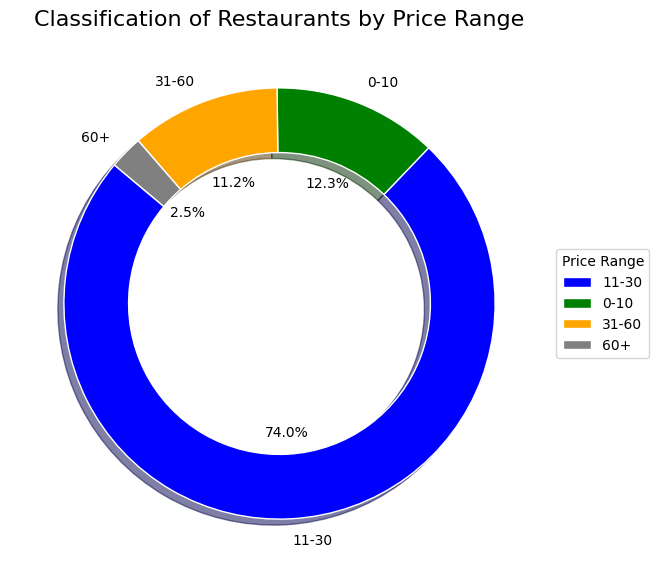

In [15]:
count_pricing = ny_clean['Price_range'].value_counts().rename_axis('Restaurant Price Range').reset_index(name='Restaurant Counts')

# Step 2: Rename symbols to actual price bands
pricing_df = count_pricing.set_index('Restaurant Price Range')
pricing_df.rename(index={
    '$': 'Under $10',
    '$$': 'Between $11-30',
    '$$$': 'Between $31-60',
    '$$$$': 'Above $60'
}, inplace=True)

# Step 3: Prepare for plotting
labels = pricing_df.index.tolist()
sizes = pricing_df['Restaurant Counts'].tolist()
colors = ['blue', 'green', 'orange', 'gray']

# Step 4: Create pie chart
fig, ax = plt.subplots(figsize=(10, 7))
ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    shadow=True,
    wedgeprops=dict(width=0.3, edgecolor='w')
)

# Add title and legend
plt.title('Classification of Restaurants by Price Range', fontsize=16)
ax.legend(title="Price Range", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

### Number of reviews by restaurant

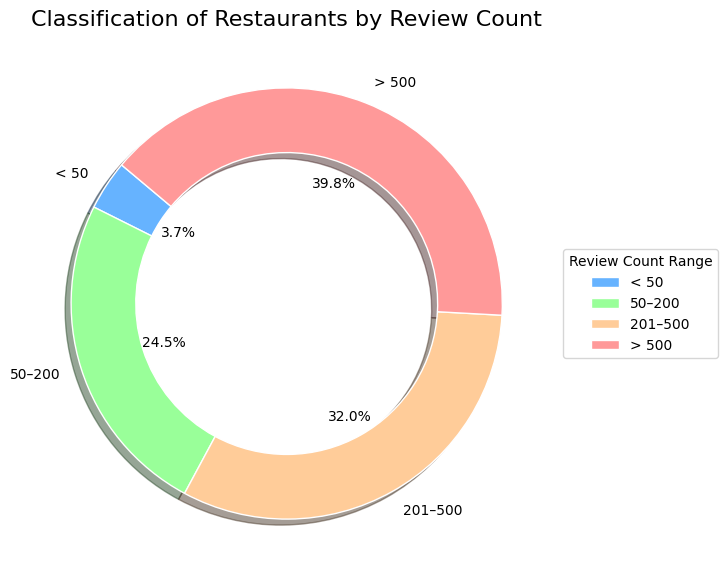

In [17]:
ny_reviews = ny_clean.copy()
bins = [0, 50, 200, 500, float('inf')]
labels = ['< 50', '50–200', '201–500', '> 500']
ny_reviews['Review Range'] = pd.cut(ny_reviews['Review Count'], bins=bins, labels=labels, include_lowest=True)

# Step 2: Count and prepare data
review_counts = ny_reviews['Review Range'].value_counts().sort_index()
colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999']

# Step 3: Pie chart
fig, ax = plt.subplots(figsize=(10, 7))
ax.pie(
    review_counts.values,
    labels=review_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    shadow=True,
    wedgeprops=dict(width=0.3, edgecolor='w')
)

plt.title("Classification of Restaurants by Review Count", fontsize=16)
ax.legend(title="Review Count Range", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.show()

## Census data exploration
- City demographics and median household income distribution

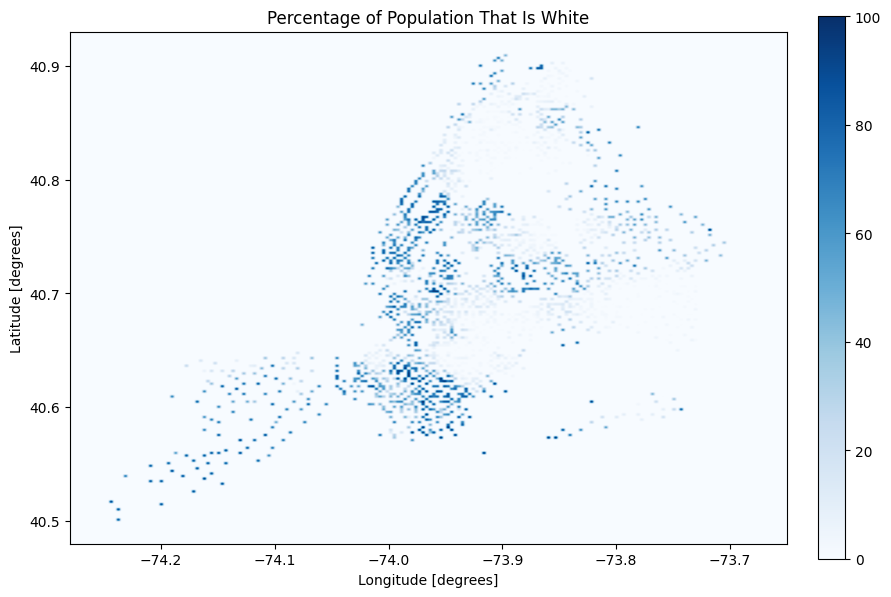

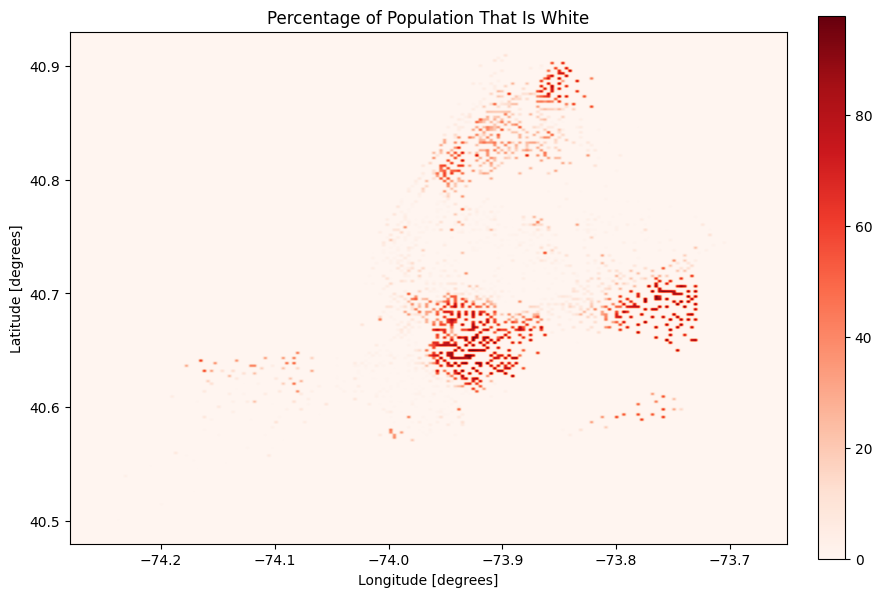

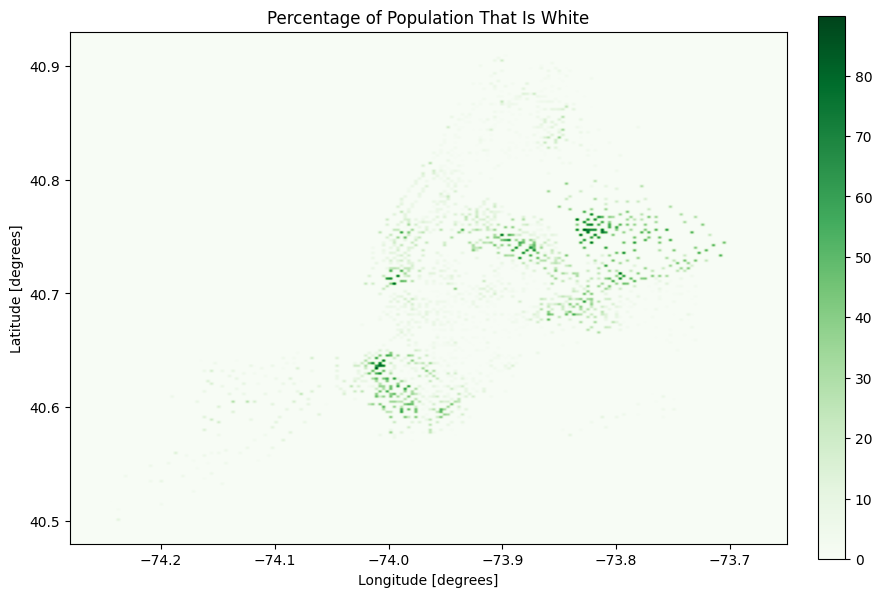

In [33]:
make_plot(census_clean.White,colors='Blues',title='Percentage of Population That Is White')
make_plot(census_clean.Black,colors='Reds',title='Percentage of Population That Is White')
make_plot(census_clean.Asian,colors='Greens',title='Percentage of Population That Is White')

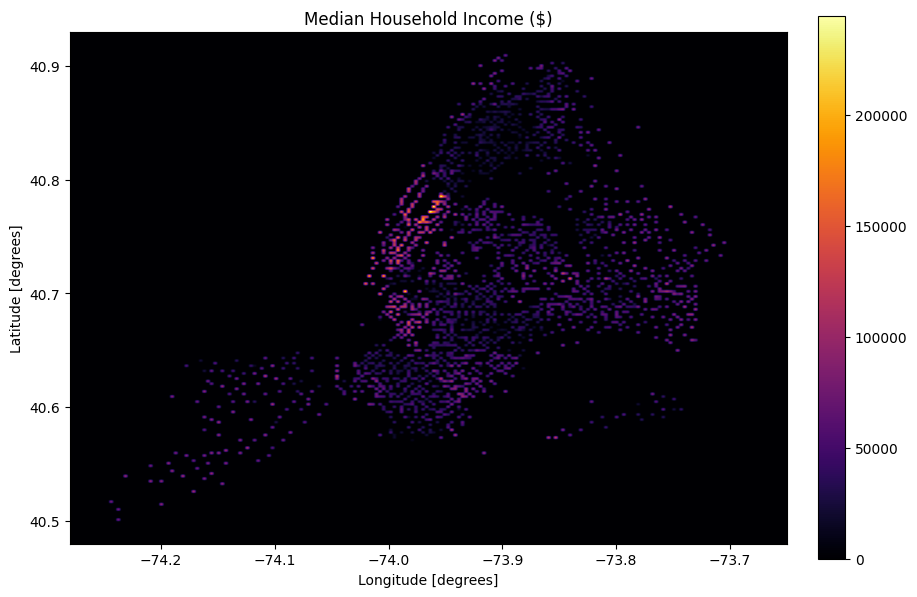

In [30]:
make_plot(census_clean.Income,colors='inferno',title='Median Household Income ($)')

# What's done

We performed extensive cleaning and transformation to prepare the dataset for spatial analysis and clustering.

- **Cleaning:** Removed rows with missing or irrelevant values, standardized column names.
- **Transformation:** Mapped price levels into numeric and semantic categories, binned review counts into ranges.
- **Augmentation:** Enriched the dataset by merging Yelp restaurant data with NYC Census data using extracted Census Tracts. This allows demographic context like income, poverty, and transportation behavior to be integrated into spatial patterns.
- **Feature Engineering:** Generated review buckets, price range categories, and applied DBSCAN clustering to identify high-density restaurant regions.

## Final Data Visualizations and Comments

We conducted detailed visualizations of restaurant data across New York City, enriched with census-based socioeconomic data. The visualizations were designed to provide insights into pricing, review volume, and potential spatial density trends:

- **Price Distribution:** A pie chart illustrated that the majority of NYC restaurants fall into the `$11–$30` price range, indicating a dominance of mid-tier establishments.
- **Review Volume:** A pie chart based on review count ranges showed that a significant portion of restaurants had fewer than 200 reviews, though a notable segment exceeded 500 reviews, representing potentially popular locations.
- **Geographic Patterns:** We produced a heatmap using `matplotlib` to show high-density review activity areas across NYC. The density was especially high in Midtown Manhattan, suggesting a strong correlation with population density, median income and white population.
- **Census Integration:** We successfully merged NYC census data with geographic coordinates. This enables future correlation analyses between business success indicators (like rating and review count) and demographic factors such as income, poverty, and transportation preferences.


# Next steps 
1. **Clustering Analysis (Pending):**
   - Apply DBSCAN or KMeans clustering to group restaurants based on spatial proximity and performance indicators like review count and rating.
   - Evaluate the characteristics of each cluster using merged census data.

2. **Deeper Socioeconomic Correlation:**
   - Explore the impact of demographic variables such as `Income`, `Poverty`, `Transit usage`, and `Walkability` on restaurant performance.
   - Identify if certain neighborhood profiles are associated with more successful restaurants.

3. **Geographic Segmentation:**
   - Segment restaurants by borough or tract and compare performance metrics.
   - Visualize outlier low-rated businesses in high-income zones, or vice versa.
